# Análisis de Datos e Inferencia Estadística
## 1. Preparación del entorno, carga y limpieza de datos
### Importación de librerías
Primero, importaremos las librerías necesarias y configuraremos nuestro entorno de análisis.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from datetime import datetime
import os


# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de visualización

In [9]:
# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de carga de archivos

In [10]:
archivos = [
    ("datasets/GRD_PUBLICO_EXTERNO_2022.txt", "utf-16"),
    ("datasets/GRD_PUBLICO_2023.txt", "utf-16"),
    ("datasets/GRD_PUBLICO_2024.txt", "latin-1"),
]

CHUNK_SIZE = 50000
output_file = "datasets/datos_limpios.csv"

# Seleccionamos las columnas a utilizar
columnas_objetivo = [
    # Identificadores y Unicidad
    'COD_HOSPITAL',
    'CIP_ENCRIPTADO',

    # Demografía (Vulnerabilidad)
    'SEXO',
    'FECHA_NACIMIENTO',
    'PREVISION',
    'COMUNA',
    
    # Gestión y Flujo (Predictores)
    'TIPO_INGRESO',
    'ESPECIALIDAD_MEDICA',
    'FECHA_INGRESO',
    'FECHAALTA',
    'USOSPABELLON',
    
    # Severidad Clínica (Predictores)
    'IR_29301_SEVERIDAD',
    'IR_29301_MORTALIDAD',
    
    # Variable Objetivo (Target)
    'TIPOALTA'
]

# Agregar dinámicamente los 35 diagnósticos y 30 procedimientos
columnas_objetivo += [f'DIAGNOSTICO{i}' for i in range(1, 10)]
columnas_objetivo += [f'PROCEDIMIENTO{i}' for i in range(1, 10)]

# 🔹 equivalencias de nombres
rename_map = {
    "ID_BENEFICIARIO": "CIP_ENCRIPTADO",
}

# 🔹 detectar columnas de fecha
data_fechas = [col for col in columnas_objetivo if "fecha" in col.lower()]

### Función para formatear fechas con distintos formatos

In [11]:
def parse_fecha(col):
    # intento 1: ISO
    fecha = pd.to_datetime(col, format="%Y-%m-%d", errors="coerce")

    # intento 2: DD-MM-YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d-%m-%Y", errors="coerce")

    # intento 3: DD/MM/YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d/%m/%Y", errors="coerce")

    return fecha

### Procesamiento de los datos

In [12]:
def procesar_datos():
    first = True

    for ruta, encoding in archivos:
        for chunk in pd.read_csv(
            ruta,
            encoding=encoding,
            sep="|",
            engine="python",
            on_bad_lines="skip",
            chunksize=CHUNK_SIZE
        ):
            # Limpiar nombres
            chunk.columns = chunk.columns.str.strip()

            # Renombrar
            chunk = chunk.rename(columns=rename_map)

            # Filtrar columnas después (más seguro)
            columnas_presentes = [c for c in columnas_objetivo if c in chunk.columns]
            chunk = chunk[columnas_presentes]

            # Agregar faltantes
            for col in columnas_objetivo:
                if col not in chunk.columns:
                    chunk[col] = pd.NA

            # Fechas
            for c in data_fechas:
                if c in chunk.columns:
                    chunk[c] = parse_fecha(chunk[c])

            # Orden final
            chunk = chunk[columnas_objetivo]

            # Guardar
            chunk.to_csv(
                output_file,
                mode="w" if first else "a",
                header=first,
                index=False,
                date_format="%Y-%m-%d"
            )

            first = False

    print("✅ Archivo generado:", output_file)

### Ajustar tipo de datos

In [13]:
dtype = {
    # IDs / códigos
    "COD_HOSPITAL": "Int32",
    "CIP_ENCRIPTADO": "string",

    # categóricos / texto
    "SEXO": "string",
    "PREVISION": "string",
    "COMUNA": "string",
    "TIPO_INGRESO": "string",
    "ESPECIALIDAD_MEDICA": "string",
    "TIPOALTA": "string",

    # numéricos
    "USOSPABELLON": "float32",
    "IR_29301_SEVERIDAD": "Int8",
    "IR_29301_MORTALIDAD": "Int8",

    # diagnósticos (códigos tipo ICD)
    "DIAGNOSTICO1": "string",
    "DIAGNOSTICO2": "string",
    "DIAGNOSTICO3": "string",
    "DIAGNOSTICO4": "string",
    "DIAGNOSTICO5": "string",
    "DIAGNOSTICO6": "string",
    "DIAGNOSTICO7": "string",
    "DIAGNOSTICO8": "string",
    "DIAGNOSTICO9": "string",

    # procedimientos (códigos numéricos)
    "PROCEDIMIENTO1": "float32",
    "PROCEDIMIENTO2": "float32",
    "PROCEDIMIENTO3": "float32",
    "PROCEDIMIENTO4": "float32",
    "PROCEDIMIENTO5": "float32",
    "PROCEDIMIENTO6": "float32",
    "PROCEDIMIENTO7": "float32",
    "PROCEDIMIENTO8": "float32",
    "PROCEDIMIENTO9": "float32",
}

fechas = [
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA"
]

### Carga de los datos

In [14]:
def cargar_o_procesar(output_file, procesar_func, force=False):
    if os.path.exists(output_file) and not force:
        print("📂 Usando archivo existente")
    else:
        print("⚙️ Generando archivo...")
        procesar_func()

    return pd.read_csv(output_file, dtype=dtype, parse_dates=fechas, na_values=["DESCONOCIDO"])

df = cargar_o_procesar("datasets/datos_limpios.csv", procesar_datos)

📂 Usando archivo existente


### Creamos variables útiles

In [15]:
df["EDAD"] = (
    (df["FECHA_INGRESO"] - df["FECHA_NACIMIENTO"])
    .dt.days // 365
)
df["AÑO"] = df["FECHA_INGRESO"].dt.year
df["DIAS_ESTADIA"] = (df["FECHAALTA"] - df["FECHA_INGRESO"]).dt.days

### Eliminar datos anteriores a 2022

In [16]:
fecha_corte = pd.Timestamp("2022-01-01")

df = df[df["FECHA_INGRESO"] >= fecha_corte]

## 2. Exploración inicial

### Revisión de la cantidad de datos

In [17]:
print(f"Cantidad de filas: {len(df)}")

Cantidad de filas: 394638


### Revisión de valores nulos

In [18]:
# Ver valores nulos
print(df.isnull().sum())

COD_HOSPITAL                0
CIP_ENCRIPTADO           1328
SEXO                       21
FECHA_NACIMIENTO            3
PREVISION                  25
COMUNA                     36
TIPO_INGRESO               16
ESPECIALIDAD_MEDICA         0
FECHA_INGRESO               0
FECHAALTA                   0
USOSPABELLON           162323
IR_29301_SEVERIDAD         11
IR_29301_MORTALIDAD        11
TIPOALTA                    0
DIAGNOSTICO1               71
DIAGNOSTICO2            54520
DIAGNOSTICO3           105244
DIAGNOSTICO4           156963
DIAGNOSTICO5           205890
DIAGNOSTICO6           247572
DIAGNOSTICO7           281508
DIAGNOSTICO8           308320
DIAGNOSTICO9           328813
PROCEDIMIENTO1             57
PROCEDIMIENTO2          26647
PROCEDIMIENTO3          56318
PROCEDIMIENTO4          85537
PROCEDIMIENTO5         115347
PROCEDIMIENTO6         145220
PROCEDIMIENTO7         175909
PROCEDIMIENTO8         206854
PROCEDIMIENTO9         236249
EDAD                        3
AÑO       

### Revisión de outliers

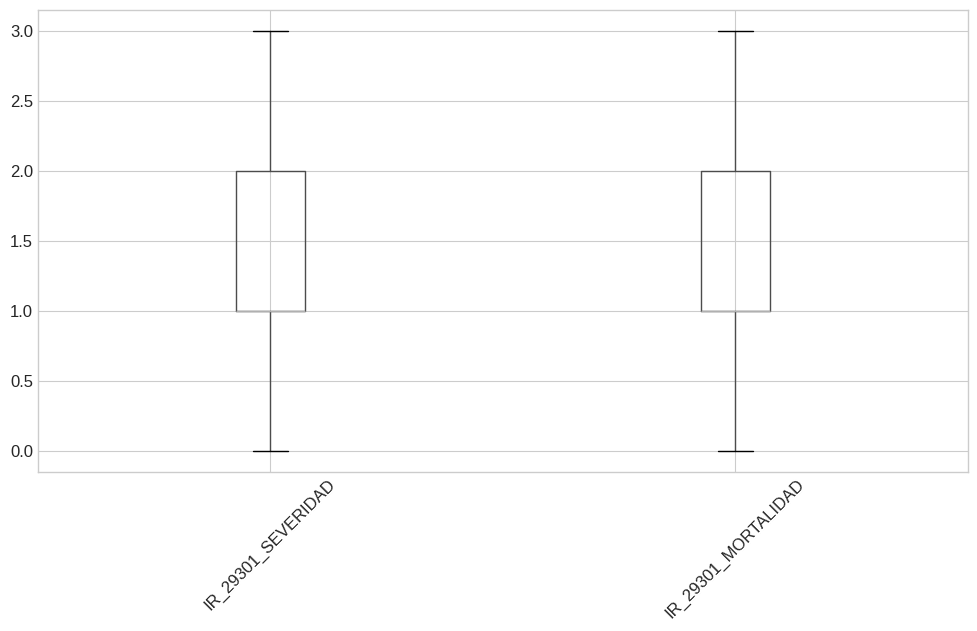

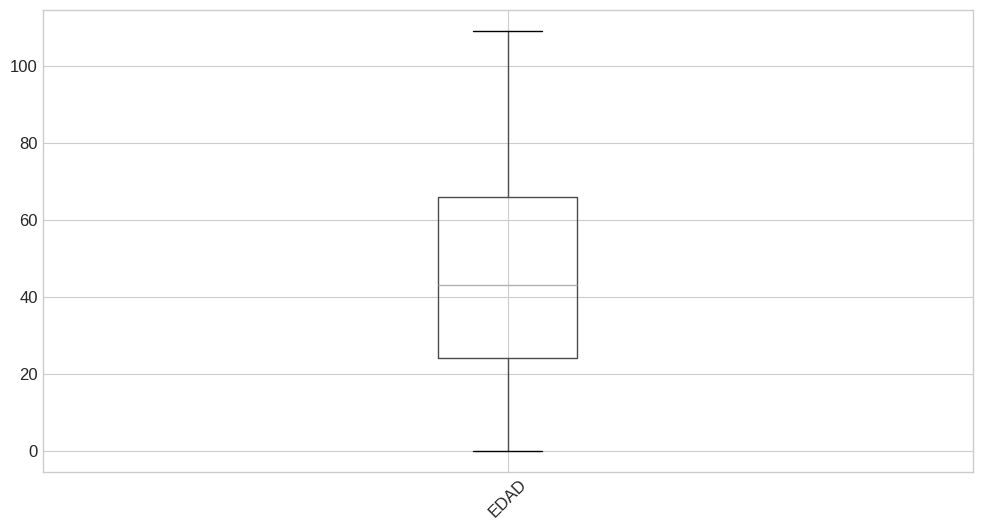

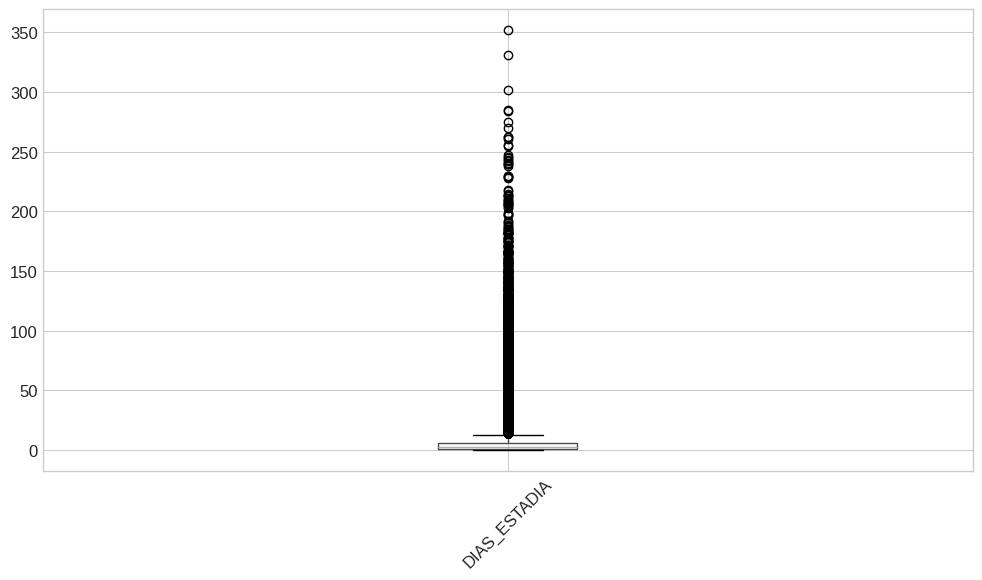

In [19]:
df.boxplot(column=["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["EDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["DIAS_ESTADIA"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [20]:
cols_numericas = ["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "EDAD", "DIAS_ESTADIA"]

Q1 = df[cols_numericas].quantile(0.25)
Q3 = df[cols_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (df[cols_numericas] < (Q1 - 1.5 * IQR)) |
    (df[cols_numericas] > (Q3 + 1.5 * IQR))
)

# por columna
print(outliers.sum())

# filas afectadas
print("Filas con outliers:", outliers.any(axis=1).sum())

IR_29301_SEVERIDAD         0
IR_29301_MORTALIDAD        0
EDAD                       0
DIAS_ESTADIA           40543
dtype: Int64
Filas con outliers: 40543


### Gráficos EDA

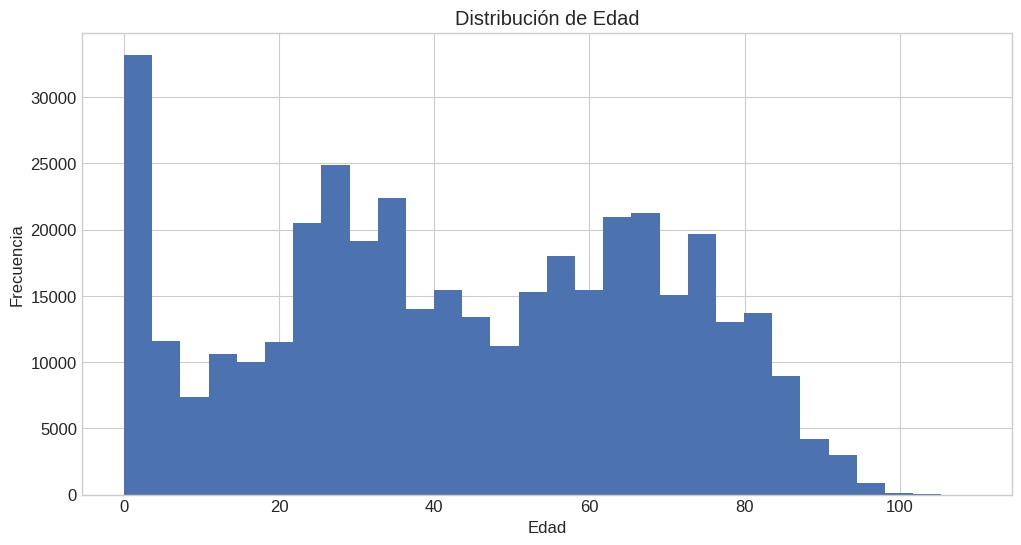

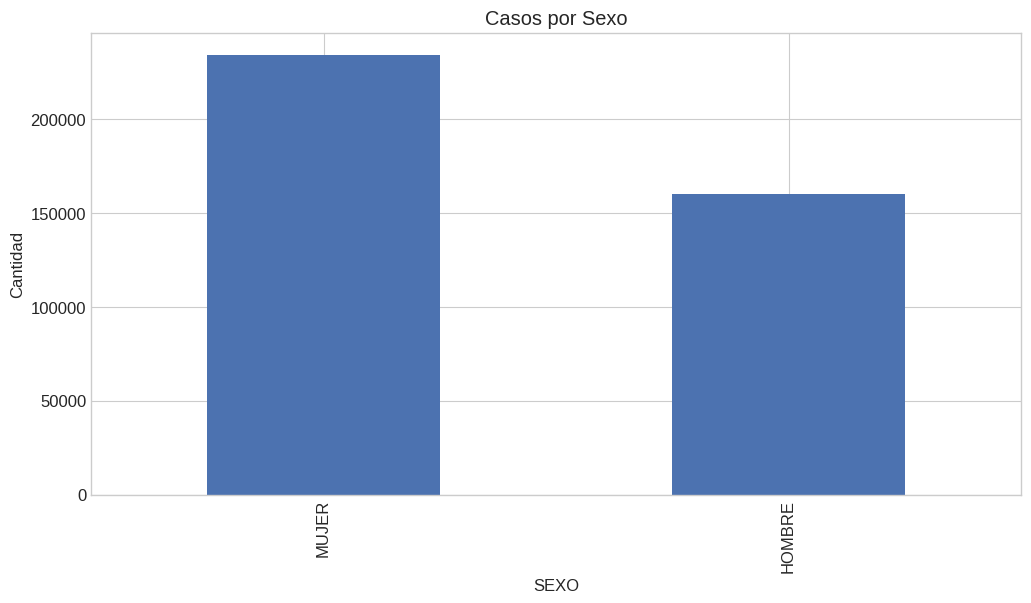

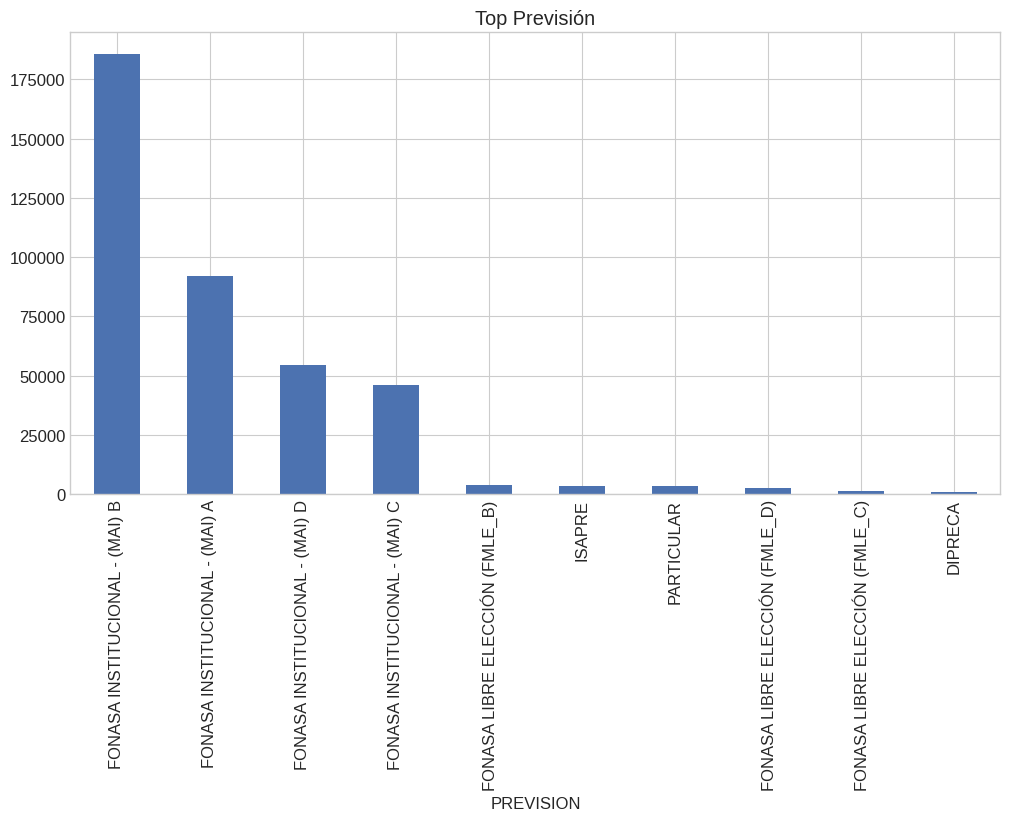

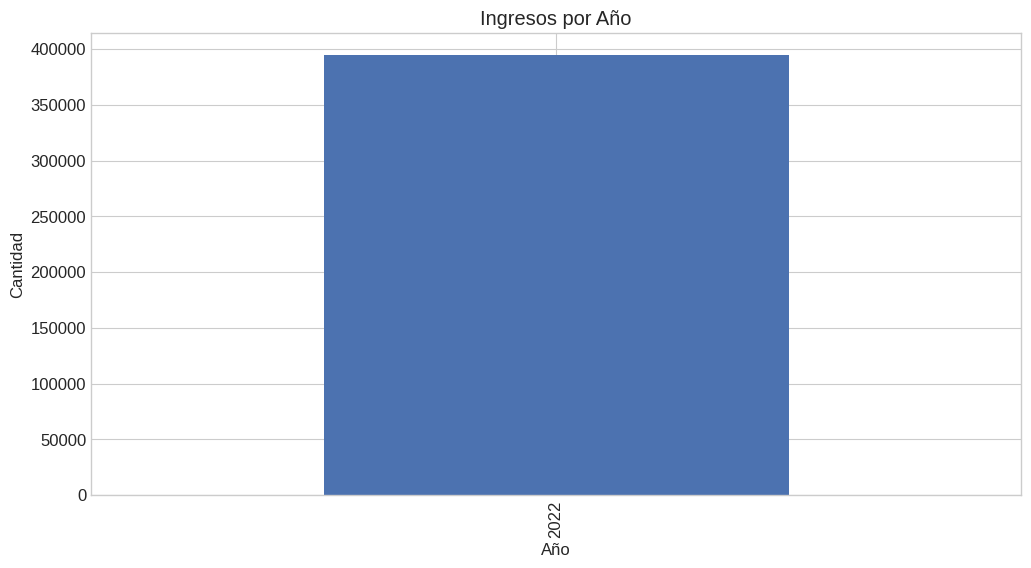

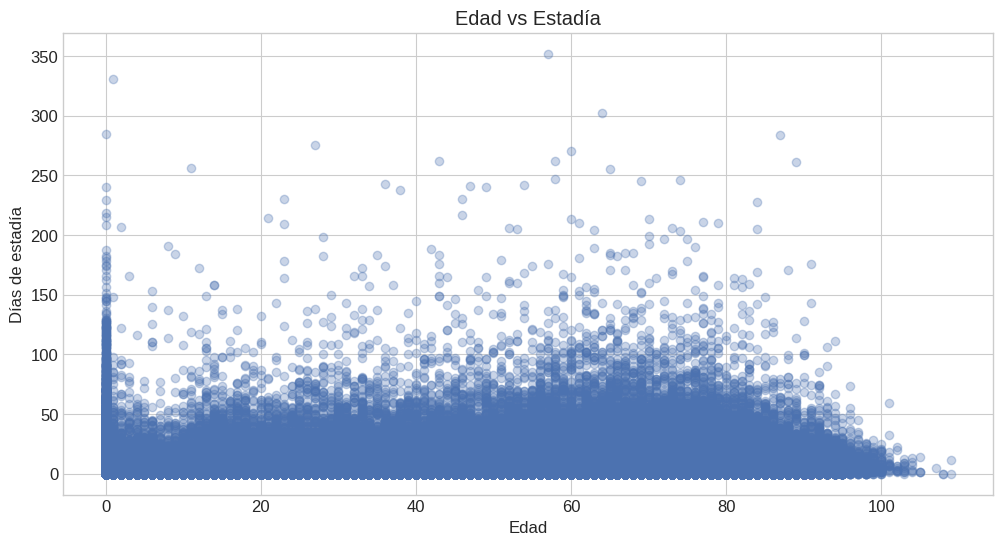

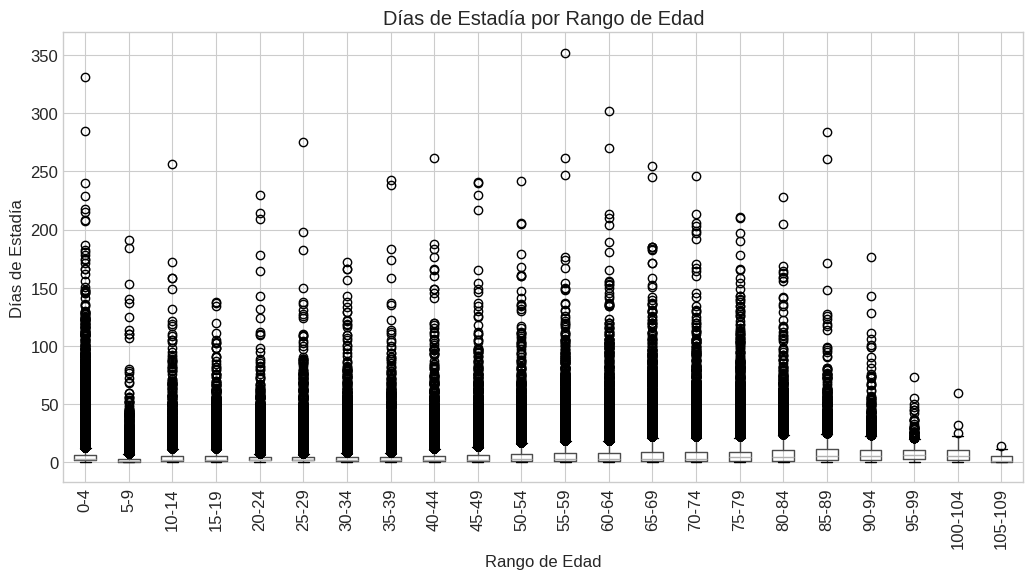

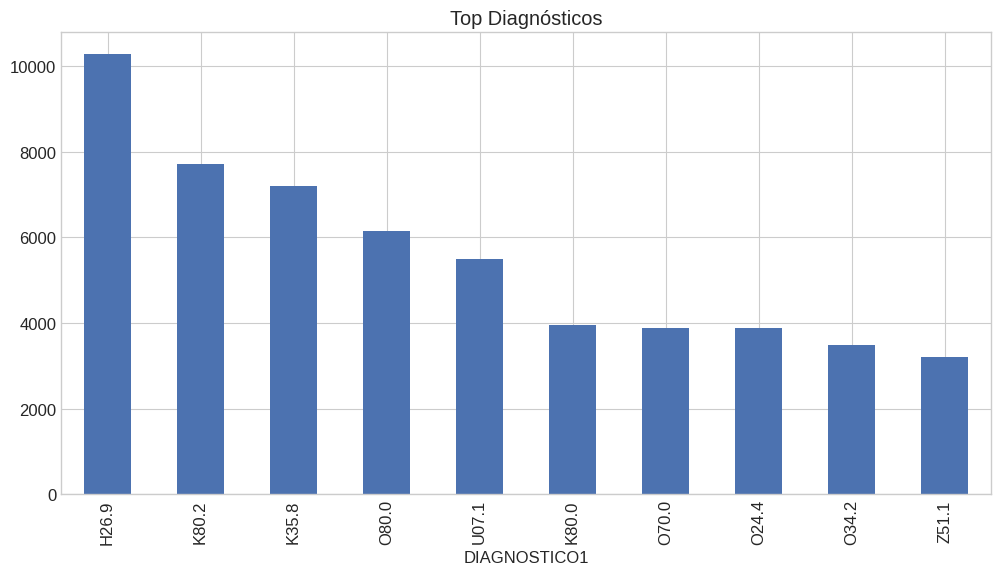

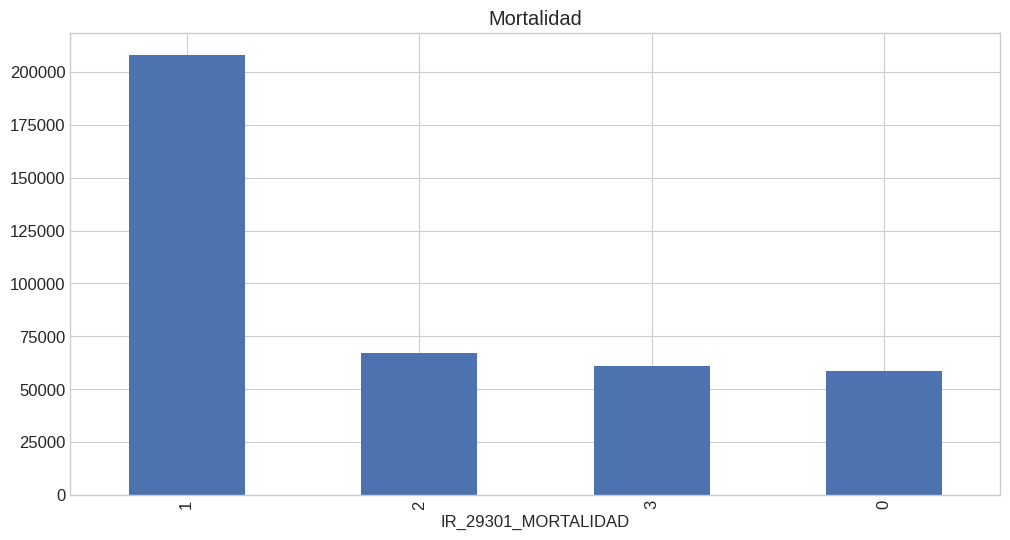

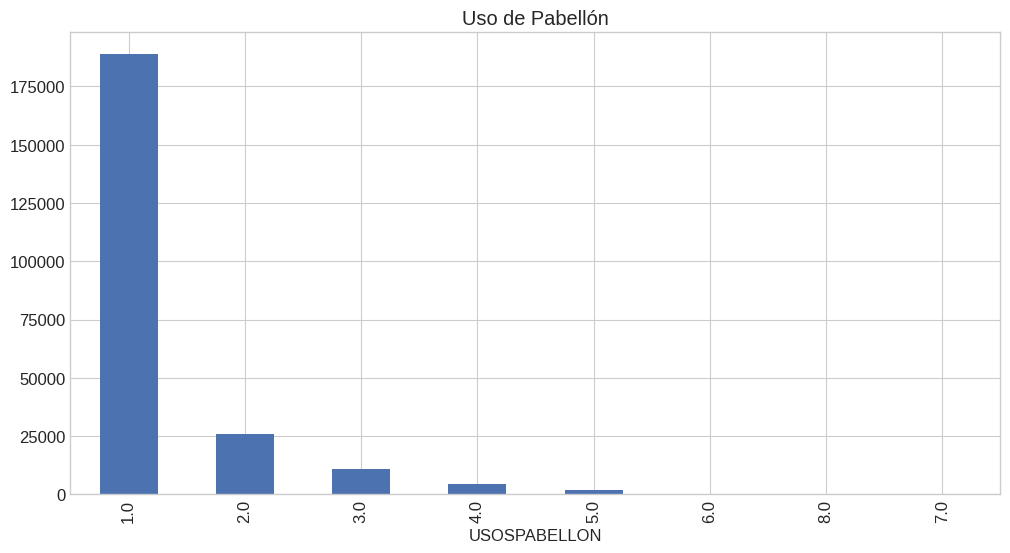

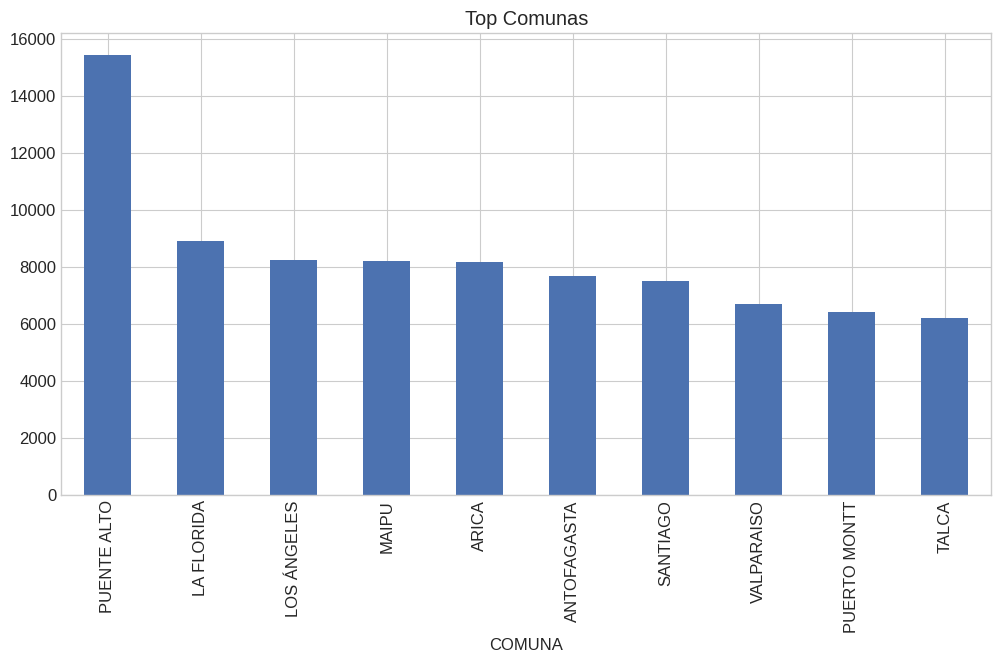

In [21]:
# Distribución de Edad
plt.figure()
df["EDAD"].hist(bins=30)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Casos por Sexo
plt.figure()
df["SEXO"].value_counts().plot(kind="bar")
plt.title("Casos por Sexo")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Cantidad")
plt.show()

# Casos por Previsión
plt.figure()
df["PREVISION"].value_counts().head(10).plot(kind="bar")
plt.title("Top Previsión")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Ingresos por Año
plt.figure()
df["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Ingresos por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Edad vs estadía
plt.figure()
plt.scatter(df["EDAD"], df["DIAS_ESTADIA"], alpha=0.3)
plt.xlabel("Edad")
plt.ylabel("Días de estadía")
plt.title("Edad vs Estadía")
plt.show()

# Edad vs estadía Boxplot
bins = np.arange(0, 115, 5)  # 0,5,10,...,120
labels = [f"{i}-{i+4}" for i in bins[:-1]]
df["rango_edad"] = pd.cut(df["EDAD"], bins=bins, labels=labels, right=False)

df.boxplot(column="DIAS_ESTADIA", by="rango_edad", rot=90)
plt.title("Días de Estadía por Rango de Edad")
plt.suptitle("")  # elimina título automático feo
plt.xlabel("Rango de Edad")
plt.ylabel("Días de Estadía")
plt.show()

# Top diagnósticos
plt.figure()
df["DIAGNOSTICO1"].value_counts().head(10).plot(kind="bar")
plt.title("Top Diagnósticos")
plt.show()

# Mortalidad
if "IR_29301_MORTALIDAD" in df.columns:
    plt.figure()
    df["IR_29301_MORTALIDAD"].value_counts().plot(kind="bar")
    plt.title("Mortalidad")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Uso de pabellón
if "USOSPABELLON" in df.columns:
    plt.figure()
    df["USOSPABELLON"].value_counts().plot(kind="bar")
    plt.title("Uso de Pabellón")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Top comunas
plt.figure()
df["COMUNA"].value_counts().head(10).plot(kind="bar")
plt.title("Top Comunas")
plt.show()

## 3. Índice de Comorbilidad de Charlson (CCI)

El Índice de Comorbilidad de Charlson (CCI) es un sistema de puntuación validado internacionalmente que cuantifica la carga de enfermedades crónicas de un paciente. Cada condición tiene un peso (1 a 6 puntos) según su impacto esperado en la mortalidad a 10 años. La suma de estos pesos constituye el score final del paciente.

Utilizamos este índice porque:
- La literatura clínica (Charlson et al., 1987; Quan et al., 2011) lo valida como predictor robusto de mortalidad intrahospitalaria.
- Nuestra hipótesis plantea que las*comorbilidades son predictores primarios — el CCI permite cuantificar exactamente esa carga.
- Los códigos ICD-10 presentes en las columnas `DIAGNOSTICO1`–`DIAGNOSTICO9` del dataset GRD permiten mapear directamente las condiciones.

### Categorías del CCI
| Score | Interpretación |
|-------|----------------|
| 0 | Sin comorbilidades relevantes |
| 1–2 | Comorbilidad leve |
| 3–4 | Comorbilidad moderada |
| ≥ 5 | Comorbilidad severa |

### Mapeo ICD-10 → Categorías Charlson

ÍNDICE DE COMORBILIDAD DE CHARLSON — IMPLEMENTACIÓN PROPIA
Referencia: Quan et al. (2011) Med Care, 49(6), 612–617.
             Charlson et al. (1987) J Chronic Dis, 40(5), 373–383.

Mapeamos prefijos ICD-10 (3 caracteres) a la categoría Charlson.
Cada categoría tiene un peso según el modelo original de Charlson
actualizado por Quan et al. (2011).

In [22]:
CHARLSON_ICD10 = {
    # ── Peso 1 ──────────────────────────────────────────────
    # Infarto agudo de miocardio
    'I21': ('MI', 1), 'I22': ('MI', 1), 'I25': ('MI', 1),
    # Insuficiencia cardíaca congestiva
    'I50': ('CHF', 1),
    # Enfermedad vascular periférica
    'I70': ('PVD', 1), 'I71': ('PVD', 1), 'I73': ('PVD', 1),
    'I77': ('PVD', 1), 'I79': ('PVD', 1),
    # Enfermedad cerebrovascular
    'G45': ('CVD', 1), 'G46': ('CVD', 1),
    'I60': ('CVD', 1), 'I61': ('CVD', 1), 'I62': ('CVD', 1),
    'I63': ('CVD', 1), 'I64': ('CVD', 1), 'I65': ('CVD', 1),
    'I66': ('CVD', 1), 'I67': ('CVD', 1), 'I68': ('CVD', 1),
    'I69': ('CVD', 1),
    # Demencia
    'F00': ('DEM', 1), 'F01': ('DEM', 1), 'F02': ('DEM', 1),
    'F03': ('DEM', 1), 'G30': ('DEM', 1), 'G31': ('DEM', 1),
    # Enfermedad pulmonar crónica (EPOC)
    'J40': ('COPD', 1), 'J41': ('COPD', 1), 'J42': ('COPD', 1),
    'J43': ('COPD', 1), 'J44': ('COPD', 1), 'J45': ('COPD', 1),
    'J46': ('COPD', 1), 'J47': ('COPD', 1), 'J60': ('COPD', 1),
    'J61': ('COPD', 1), 'J62': ('COPD', 1), 'J63': ('COPD', 1),
    'J64': ('COPD', 1), 'J65': ('COPD', 1), 'J66': ('COPD', 1),
    'J67': ('COPD', 1),
    # Enfermedad del tejido conectivo
    'M05': ('RHD', 1), 'M06': ('RHD', 1), 'M32': ('RHD', 1),
    'M33': ('RHD', 1), 'M34': ('RHD', 1), 'M35': ('RHD', 1),
    # Úlcera péptica
    'K25': ('PUD', 1), 'K26': ('PUD', 1), 'K27': ('PUD', 1),
    'K28': ('PUD', 1),
    # Enfermedad hepática leve
    'B18': ('MLD', 1), 'K70': ('MLD', 1), 'K71': ('MLD', 1),
    'K73': ('MLD', 1), 'K74': ('MLD', 1), 'K76': ('MLD', 1),
    # Diabetes sin complicación
    'E10': ('DM', 1), 'E11': ('DM', 1), 'E12': ('DM', 1),
    'E13': ('DM', 1), 'E14': ('DM', 1),

    # ── Peso 2 ──────────────────────────────────────────────
    # Hemiplejia
    'G04': ('HEMI', 2), 'G81': ('HEMI', 2), 'G82': ('HEMI', 2),
    'G83': ('HEMI', 2),
    # Enfermedad renal moderada/severa
    'N03': ('REN', 2), 'N05': ('REN', 2), 'N18': ('REN', 2),
    'N19': ('REN', 2), 'N25': ('REN', 2),
    # Diabetes con complicación crónica
    'E102': ('DMC', 2), 'E112': ('DMC', 2), 'E122': ('DMC', 2),
    'E132': ('DMC', 2), 'E142': ('DMC', 2),
    # Tumor sólido sin metástasis
    'C00': ('TUM', 2), 'C01': ('TUM', 2), 'C02': ('TUM', 2),
    'C03': ('TUM', 2), 'C04': ('TUM', 2), 'C05': ('TUM', 2),
    'C06': ('TUM', 2), 'C07': ('TUM', 2), 'C08': ('TUM', 2),
    'C09': ('TUM', 2), 'C10': ('TUM', 2), 'C11': ('TUM', 2),
    'C12': ('TUM', 2), 'C13': ('TUM', 2), 'C14': ('TUM', 2),
    'C15': ('TUM', 2), 'C16': ('TUM', 2), 'C17': ('TUM', 2),
    'C18': ('TUM', 2), 'C19': ('TUM', 2), 'C20': ('TUM', 2),
    'C21': ('TUM', 2), 'C22': ('TUM', 2), 'C23': ('TUM', 2),
    'C24': ('TUM', 2), 'C25': ('TUM', 2), 'C26': ('TUM', 2),
    'C30': ('TUM', 2), 'C31': ('TUM', 2), 'C32': ('TUM', 2),
    'C33': ('TUM', 2), 'C34': ('TUM', 2), 'C37': ('TUM', 2),
    'C38': ('TUM', 2), 'C39': ('TUM', 2), 'C40': ('TUM', 2),
    'C41': ('TUM', 2), 'C43': ('TUM', 2), 'C45': ('TUM', 2),
    'C46': ('TUM', 2), 'C47': ('TUM', 2), 'C48': ('TUM', 2),
    'C49': ('TUM', 2), 'C50': ('TUM', 2), 'C51': ('TUM', 2),
    'C52': ('TUM', 2), 'C53': ('TUM', 2), 'C54': ('TUM', 2),
    'C55': ('TUM', 2), 'C56': ('TUM', 2), 'C57': ('TUM', 2),
    'C58': ('TUM', 2), 'C60': ('TUM', 2), 'C61': ('TUM', 2),
    'C62': ('TUM', 2), 'C63': ('TUM', 2), 'C64': ('TUM', 2),
    'C65': ('TUM', 2), 'C66': ('TUM', 2), 'C67': ('TUM', 2),
    'C68': ('TUM', 2), 'C69': ('TUM', 2), 'C70': ('TUM', 2),
    'C71': ('TUM', 2), 'C72': ('TUM', 2), 'C73': ('TUM', 2),
    'C74': ('TUM', 2), 'C75': ('TUM', 2), 'C76': ('TUM', 2),
    'C97': ('TUM', 2),
    # Leucemia
    'C91': ('LEU', 2), 'C92': ('LEU', 2), 'C93': ('LEU', 2),
    'C94': ('LEU', 2), 'C95': ('LEU', 2),
    # Linfoma
    'C81': ('LYM', 2), 'C82': ('LYM', 2), 'C83': ('LYM', 2),
    'C84': ('LYM', 2), 'C85': ('LYM', 2), 'C88': ('LYM', 2),
    'C90': ('LYM', 2),

    # ── Peso 3 ──────────────────────────────────────────────
    # Enfermedad hepática moderada/severa
    'K70': ('MSLD', 3), 'K72': ('MSLD', 3), 'K76': ('MSLD', 3),

    # ── Peso 6 ──────────────────────────────────────────────
    # Tumor sólido con metástasis
    'C77': ('METS', 6), 'C78': ('METS', 6),
    'C79': ('METS', 6), 'C80': ('METS', 6),
    # VIH / SIDA
    'B20': ('AIDS', 6), 'B21': ('AIDS', 6),
    'B22': ('AIDS', 6), 'B24': ('AIDS', 6),
}

print(f"Mapa Charlson cargado: {len(CHARLSON_ICD10)} prefijos ICD-10 mapeados")
print(f"Categorías únicas: {len(set(v[0] for v in CHARLSON_ICD10.values()))}")

Mapa Charlson cargado: 169 prefijos ICD-10 mapeados
Categorías únicas: 19


### Función de cálculo del CCI por paciente

In [23]:
def match_charlson(codigo: str) -> tuple | None:
    """
    Recibe un código ICD-10 (ej: 'I5000', 'J44', 'C34X').
    Devuelve (categoria, peso) si hay match, o None si no aplica.
    
    Estrategia: probar prefijos de longitud 5, 4 y 3 en orden.
    Esto permite capturar tanto los códigos de 5 dígitos (diabetes
    con complicación, ej 'E102') como los genéricos de 3 dígitos.
    """
    if not isinstance(codigo, str):
        return None
    # Normalizar: mayúsculas, sin espacios, sin guiones
    cod = codigo.upper().strip().replace('-', '').replace(' ', '')
    # Intentar match por prefijo decreciente (5 → 4 → 3 chars)
    for length in (5, 4, 3):
        prefijo = cod[:length]
        if prefijo in CHARLSON_ICD10:
            return CHARLSON_ICD10[prefijo]
    return None


# Columnas de diagnóstico disponibles en el dataset
COLS_DIAGNOSTICO = [f'DIAGNOSTICO{i}' for i in range(1, 10)]


def calcular_cci(fila: pd.Series, cols_dx: list[str]) -> int:
    """
    Calcula el Índice de Comorbilidad de Charlson para una fila del dataframe.
    
    Parámetros
    ----------
    fila     : pd.Series — una fila del dataframe
    cols_dx  : list[str] — nombres de columnas de diagnóstico ICD-10
    
    Retorna
    -------
    int — score CCI (0 = sin comorbilidades)
    
    Nota: cada categoría Charlson se cuenta UNA sola vez, aunque el
    paciente tenga múltiples diagnósticos que caigan en la misma.
    """
    categorias_presentes = {}  # {categoria: peso}
    
    for col in cols_dx:
        codigo = fila.get(col)
        resultado = match_charlson(codigo)
        if resultado is not None:
            categoria, peso = resultado
            # Guardar el peso más alto si hay categorías duplicadas
            if categoria not in categorias_presentes:
                categorias_presentes[categoria] = peso
            else:
                categorias_presentes[categoria] = max(
                    categorias_presentes[categoria], peso
                )
    
    return sum(categorias_presentes.values())


print("Funciones match_charlson() y calcular_cci() definidas")

# Test unitario rápido
test_cases = [
    ('I50', 'CHF', 1),
    ('J440', 'COPD', 1),
    ('C34',  'TUM', 2),
    ('C79',  'METS', 6),
    ('B20',  'AIDS', 6),
    ('XYZ',  None, None),
]
print("\nTest unitario match_charlson():")
all_ok = True
for cod, cat_esperada, peso_esperado in test_cases:
    result = match_charlson(cod)
    if cat_esperada is None:
        ok = result is None
    else:
        ok = result is not None and result[0] == cat_esperada and result[1] == peso_esperado
    status = '✅' if ok else '❌'
    if not ok:
        all_ok = False
    print(f"{status} '{cod}' → esperado ({cat_esperada}, {peso_esperado}), obtenido {result}")
print("\nTodos los tests OK" if all_ok else "\n Revisar tests fallidos")

Funciones match_charlson() y calcular_cci() definidas

Test unitario match_charlson():
✅ 'I50' → esperado (CHF, 1), obtenido ('CHF', 1)
✅ 'J440' → esperado (COPD, 1), obtenido ('COPD', 1)
✅ 'C34' → esperado (TUM, 2), obtenido ('TUM', 2)
✅ 'C79' → esperado (METS, 6), obtenido ('METS', 6)
✅ 'B20' → esperado (AIDS, 6), obtenido ('AIDS', 6)
✅ 'XYZ' → esperado (None, None), obtenido None

Todos los tests OK


### Aplicación al dataset: columna `CCI`

Aplicamos `calcular_cci()` a cada fila del dataframe usando `.apply()`. El resultado se guarda en la nueva columna `CCI`.

> **Nota de rendimiento**: con datasets grandes (~millones de filas), `.apply()` fila a fila puede ser lento. Si el tiempo de cómputo es crítico, el siguiente enfoque vectorizado por columna de diagnóstico es notablemente más rápido — está incluido como alternativa comentada al final de la celda.

Verificar que las columnas de diagnóstico existen en df

In [24]:
cols_disponibles = [c for c in COLS_DIAGNOSTICO if c in df.columns]
cols_faltantes   = [c for c in COLS_DIAGNOSTICO if c not in df.columns]

if cols_faltantes:
    print(f"Columnas no encontradas (se ignorarán): {cols_faltantes}")
print(f"Columnas de diagnóstico disponibles: {cols_disponibles}")

Columnas de diagnóstico disponibles: ['DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOSTICO7', 'DIAGNOSTICO8', 'DIAGNOSTICO9']


Calcular CCI

In [25]:
print("\nCalculando CCI...")
df['CCI'] = df.apply(
    calcular_cci,
    cols_dx=cols_disponibles,
    axis=1
)
print(f"Columna 'CCI' creada. Shape: {df.shape}")


Calculando CCI...
Columna 'CCI' creada. Shape: (394638, 37)


### Distribución del CCI y categorización

Crear variable categórica

In [26]:
bins   = [-1, 0, 2, 4, 100]
labels = ['Sin comorbilidades (0)',
          'Leve (1–2)',
          'Moderada (3–4)',
          'Severa (≥5)']

df['CCI_CAT'] = pd.cut(df['CCI'], bins=bins, labels=labels)

Estadísticas descriptivas

In [27]:
print("=== Estadísticas del CCI ===")
print(df['CCI'].describe().round(3))

print("\n=== Distribución por categoría ===")
dist = df['CCI_CAT'].value_counts().sort_index()
print(dist)
print(f"\nPorcentajes:")
print((dist / len(df) * 100).round(2))

=== Estadísticas del CCI ===
count    394638.000
mean          0.875
std           1.577
min           0.000
25%           0.000
50%           0.000
75%           1.000
max          17.000
Name: CCI, dtype: float64

=== Distribución por categoría ===
CCI_CAT
Sin comorbilidades (0)    247438
Leve (1–2)                100830
Moderada (3–4)             33034
Severa (≥5)                13336
Name: count, dtype: int64

Porcentajes:
CCI_CAT
Sin comorbilidades (0)    62.70
Leve (1–2)                25.55
Moderada (3–4)             8.37
Severa (≥5)                3.38
Name: count, dtype: float64


Visualización: distribución del CCI

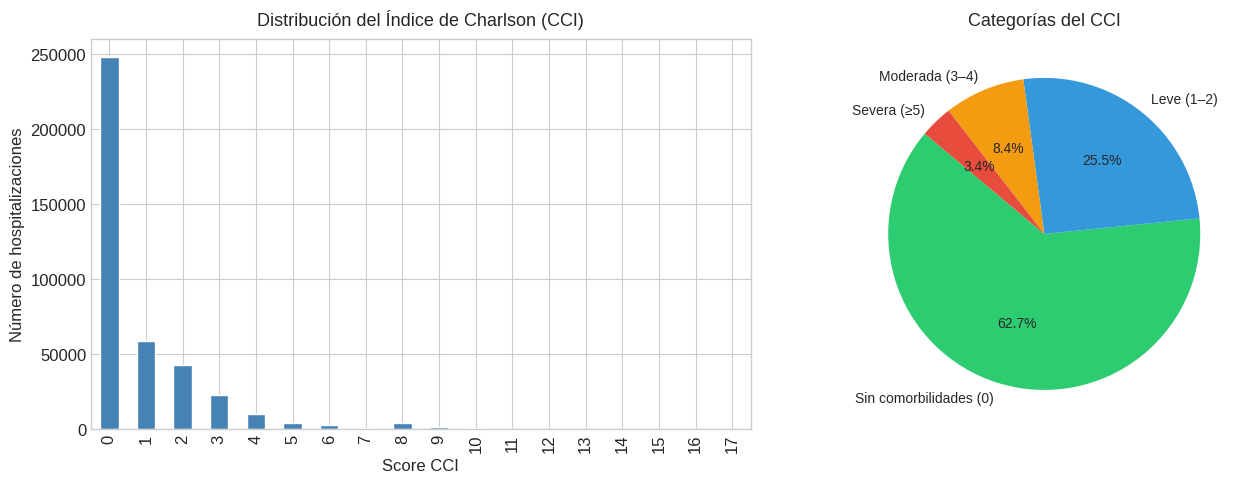

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores
ax1 = axes[0]
df['CCI'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_title('Distribución del Índice de Charlson (CCI)', fontsize=13, pad=10)
ax1.set_xlabel('Score CCI')
ax1.set_ylabel('Número de hospitalizaciones')
ax1.ticklabel_format(style='plain', axis='y')

# Pie por categoría
ax2 = axes[1]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
df['CCI_CAT'].value_counts().sort_index().plot(
    kind='pie', ax=ax2, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 10}
)
ax2.set_title('Categorías del CCI', fontsize=13, pad=10)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

### CCI vs Mortalidad intrahospitalaria

Exploramos si existe una relación visible entre la carga de comorbilidades (CCI) y la mortalidad durante la hospitalización (`TIPOALTA`). Esto constituye el análisis exploratorio central de nuestra pregunta de investigación.

Crear variable binaria de mortalidad

In [29]:
# TIPOALTA = '2' corresponde a fallecimiento en la mayoría de codificaciones GRD
# Ajustar el valor si el dataset usa otra codificación
df['FALLECIDO'] = df['TIPOALTA'].astype(str).str.strip().isin(['2', '02', 'FALLECIDO'])

print(f"Registros con fallecimiento: {df['FALLECIDO'].sum():,}")
print(f"Tasa de mortalidad global: {df['FALLECIDO'].mean():.3%}")

Registros con fallecimiento: 11,372
Tasa de mortalidad global: 2.882%


Tasa de mortalidad por categoría CCI

In [30]:
mortalidad_por_cci = (
    df.groupby('CCI_CAT', observed=True)['FALLECIDO']
      .agg(['sum', 'mean', 'count'])
      .rename(columns={'sum': 'Fallecidos', 'mean': 'Tasa', 'count': 'Total'})
)
mortalidad_por_cci['Tasa_%'] = (mortalidad_por_cci['Tasa'] * 100).round(2)

print("\n=== Mortalidad por categoría CCI ===")
print(mortalidad_por_cci[['Total', 'Fallecidos', 'Tasa_%']])


=== Mortalidad por categoría CCI ===
                         Total  Fallecidos  Tasa_%
CCI_CAT                                           
Sin comorbilidades (0)  247438        2252    0.91
Leve (1–2)              100830        4843    4.80
Moderada (3–4)           33034        2831    8.57
Severa (≥5)              13336        1446   10.84


Visualización: CCI vs mortalidad

/tmp/ipykernel_25598/2291394797.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cats, rotation=15, ha='right')


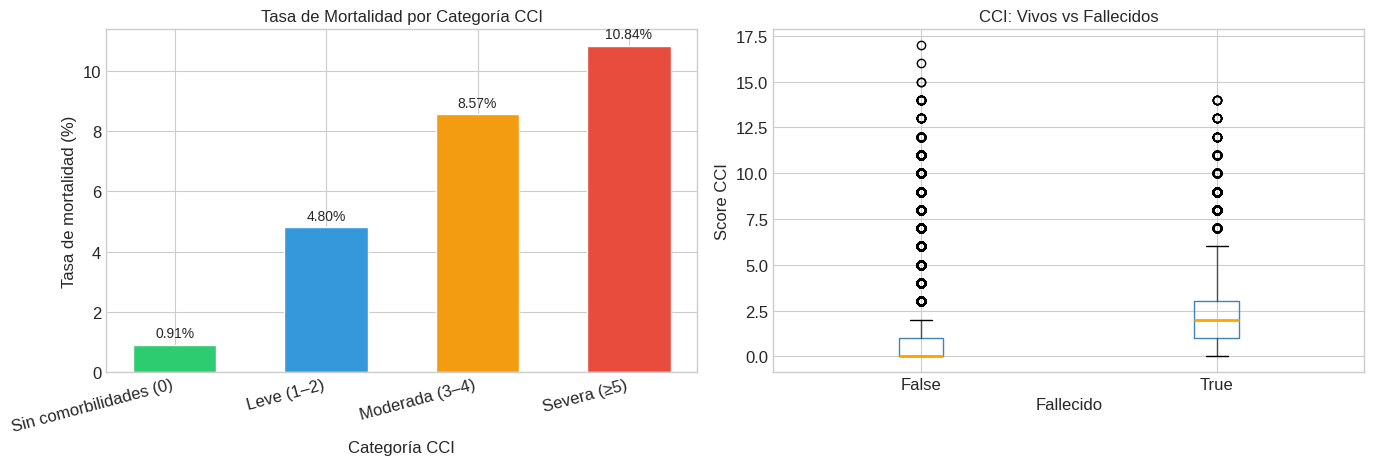

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: tasa de mortalidad por categoría
ax1 = axes[0]
cats = mortalidad_por_cci.index.astype(str)
tasas = mortalidad_por_cci['Tasa_%']
bars = ax1.bar(cats, tasas, color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
               edgecolor='white', width=0.55)
ax1.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax1.set_title('Tasa de Mortalidad por Categoría CCI', fontsize=12)
ax1.set_xlabel('Categoría CCI')
ax1.set_ylabel('Tasa de mortalidad (%)')
ax1.set_xticklabels(cats, rotation=15, ha='right')

# Gráfico 2: boxplot CCI (vivos vs fallecidos)
ax2 = axes[1]
df.boxplot(
    column='CCI', by='FALLECIDO', ax=ax2,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='orange', linewidth=2)
)
ax2.set_title('CCI: Vivos vs Fallecidos', fontsize=12)
ax2.set_xlabel('Fallecido')
ax2.set_ylabel('Score CCI')
plt.suptitle('')  # elimina el título automático de boxplot

plt.tight_layout()
plt.show()

### Estimación estadística: CCI como predictor

Calculamos estimadores puntuales del CCI separando pacientes fallecidos de los no fallecidos, y construimos intervalos de confianza al 95% para la media del CCI en cada grupo.

Estimadores por grupo

In [32]:
grupos = {
    'Vivos':     df[df['FALLECIDO'] == False]['CCI'].dropna(),
    'Fallecidos': df[df['FALLECIDO'] == True]['CCI'].dropna(),
}

print(f"{'Grupo':<14} {'n':>8} {'Media':>8} {'Mediana':>9} {'Std':>8} {'IC95% inf':>11} {'IC95% sup':>11}")
print("-" * 75)

for nombre, serie in grupos.items():
    n     = len(serie)
    media = serie.mean()
    med   = serie.median()
    std   = serie.std()
    sem   = scipy_stats.sem(serie)
    ci    = scipy_stats.t.interval(0.95, df=n-1, loc=media, scale=sem)
    print(f"{nombre:<14} {n:>8,} {media:>8.3f} {med:>9.1f} {std:>8.3f} "
          f"{ci[0]:>11.3f} {ci[1]:>11.3f}")

Grupo                 n    Media   Mediana      Std   IC95% inf   IC95% sup
---------------------------------------------------------------------------
Vivos           383,266    0.831       0.0    1.529       0.826       0.836
Fallecidos       11,372    2.365       2.0    2.274       2.324       2.407


Prueba Mann-Whitney (distribución no normal esperada)

In [33]:
print("\n=== Prueba Mann-Whitney U (CCI: Vivos vs Fallecidos) ===")
stat, p_val = scipy_stats.mannwhitneyu(
    grupos['Vivos'], grupos['Fallecidos'], alternative='less'
)
print(f"Estadístico U = {stat:.2f}")
print(f"p-valor       = {p_val:.4e}")
if p_val < 0.05:
    print("→ Diferencia estadísticamente significativa (α=0.05)")
    print("→ Los pacientes fallecidos tienen un CCI mayor en promedio.")
else:
    print("→ No se detecta diferencia significativa al nivel α=0.05")


=== Prueba Mann-Whitney U (CCI: Vivos vs Fallecidos) ===
Estadístico U = 1092568650.00
p-valor       = 0.0000e+00
→ Diferencia estadísticamente significativa (α=0.05)
→ Los pacientes fallecidos tienen un CCI mayor en promedio.


## 4. Tabla Resumen de Estimadores Estadísticos

Tabla consolidada de los principales estimadores puntuales calculados sobre las variables de interés, comparando grupos según mortalidad.

Tabla resumen de estimadores por variable numérica y grupo

In [34]:
vars_interes = ['CCI', 'EDAD', 'DIAS_ESTADIA',
                'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD']

vars_presentes = [v for v in vars_interes if v in df.columns]

filas = []
for var in vars_presentes:
    for fallecido, label in [(False, 'Vivo'), (True, 'Fallecido')]:
        serie = df[df['FALLECIDO'] == fallecido][var].dropna()
        n = len(serie)
        if n < 2:
            continue
        sem = scipy_stats.sem(serie)
        ci  = scipy_stats.t.interval(0.95, df=n-1, loc=serie.mean(), scale=sem)
        filas.append({
            'Variable': var,
            'Grupo': label,
            'n': n,
            'Media': round(serie.mean(), 3),
            'Mediana': round(serie.median(), 3),
            'Std': round(serie.std(), 3),
            'P25': round(serie.quantile(0.25), 3),
            'P75': round(serie.quantile(0.75), 3),
            'IC95_inf': round(ci[0], 3),
            'IC95_sup': round(ci[1], 3),
        })

tabla_resumen = pd.DataFrame(filas)
display(tabla_resumen)

,Variable,Grupo,n,Media,Mediana,Std,P25,P75,IC95_inf,IC95_sup
0,CCI,Vivo,383266,0.831,0.0,1.529,0.0,1.0,0.826,0.836
1,CCI,Fallecido,11372,2.365,2.0,2.274,1.0,3.0,2.324,2.407
2,EDAD,Vivo,383263,42.897,41.0,25.429,24.0,65.0,42.817,42.978
3,EDAD,Fallecido,11372,69.267,73.0,19.109,61.0,82.0,68.916,69.618
4,DIAS_ESTADIA,Vivo,383266,5.512,3.0,9.816,1.0,6.0,5.481,5.543
5,DIAS_ESTADIA,Fallecido,11372,11.779,6.0,17.143,2.0,14.0,11.464,12.094
6,IR_29301_SEVERIDAD,Vivo,383265,1.452,1.0,0.958,1.0,2.0,1.449,1.455
7,IR_29301_SEVERIDAD,Fallecido,11362,2.831,3.0,0.466,3.0,3.0,2.822,2.839
8,IR_29301_MORTALIDAD,Vivo,383265,1.288,1.0,0.883,1.0,2.0,1.285,1.291
9,IR_29301_MORTALIDAD,Fallecido,11362,2.790,3.0,0.500,3.0,3.0,2.781,2.800


---
## 5. Pruebas de Hipotesis Aplicadas al Proyecto


**Pregunta**: ¿El CCI difiere entre fallecidos y vivos?

**Variables**: CCI, FALLECIDO

**Prueba**: Mann-Whitney U



### 4.0 Preparacion: variables necesarias

In [35]:
# Verificamos que las variables del proyecto esten disponibles en df.
# Si el dataset no esta cargado, ejecutar primero las secciones 1-3.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

# TIPOALTA = '2' corresponde a fallecimiento en la codificacion GRD chilena
df['FALLECIDO'] = df['TIPOALTA'].astype(str).str.strip().isin(['FALLECIDO'])

# Insuficiencia cardiaca (mish)
cols_dx = [c for c in df.columns if c.startswith('DIAGNOSTICO')]
df['IC'] = df[cols_dx].apply(
    lambda row: any(str(v).upper().startswith('I50') for v in row if pd.notna(v)),
    axis=1
)

# Resumen de variables creadas
print("Variables disponibles para pruebas de hipotesis:")
print(f"  FALLECIDO  : {df['FALLECIDO'].sum():,} fallecidos de {len(df):,} registros ({df['FALLECIDO'].mean():.2%})")
print(f"  IC         : {df['IC'].sum():,} pacientes con I50.x ({df['IC'].mean():.2%})")
print(f"  CCI        : media={df['CCI'].mean():.3f}, mediana={df['CCI'].median():.1f}")
print(f"  DIAS_ESTADIA: media={df['DIAS_ESTADIA'].mean():.2f}, mediana={df['DIAS_ESTADIA'].median():.1f}")


Variables disponibles para pruebas de hipotesis:
  FALLECIDO  : 11,372 fallecidos de 394,638 registros (2.88%)
  IC         : 15,926 pacientes con I50.x (4.04%)
  CCI        : media=0.875, mediana=0.0
  DIAS_ESTADIA: media=5.69, mediana=3.0


### 4.1 Mann-Whitney U: CCI en fallecidos vs vivos

**Pregunta:** ¿La carga de comorbilidades (CCI) es significativamente mayor en
pacientes que fallecen durante la hospitalizacion?

**Justificacion de la prueba:** el CCI tiene distribucion fuertemente asimetrica
(muchos pacientes con score 0, pocos con scores altos). No podemos asumir normalidad
de la distribucion individual aunque el TCL aplique a las medias. Mann-Whitney U es
el equivalente no parametrico de la t para dos muestras independientes y trabaja
con rangos, siendo robusto frente a esta asimetria.

- H0: La distribucion del CCI es igual en fallecidos y vivos
- H1: El CCI es mayor en fallecidos que en vivos (unilateral)
- $\alpha$ = 0.05


In [36]:
#  Mann-Whitney U - CCI en fallecidos vs vivos

cci_fallecidos = df[df['FALLECIDO'] == True]['CCI'].dropna()
cci_vivos      = df[df['FALLECIDO'] == False]['CCI'].dropna()

u_stat, p_valor_mw = scipy_stats.mannwhitneyu(
    cci_fallecidos, cci_vivos, alternative='greater'
)

# Tamanio del efecto: estadistico r = Z / sqrt(N)
n1, n2 = len(cci_fallecidos), len(cci_vivos)
z_approx = (u_stat - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
r_effect  = abs(z_approx) / np.sqrt(n1 + n2)

print(f"  Fallecidos  n={n1:,}: media={cci_fallecidos.mean():.3f}  mediana={cci_fallecidos.median():.1f}  P25-P75=[{cci_fallecidos.quantile(.25):.1f}, {cci_fallecidos.quantile(.75):.1f}]")
print(f"  Vivos       n={n2:,}: media={cci_vivos.mean():.3f}  mediana={cci_vivos.median():.1f}  P25-P75=[{cci_vivos.quantile(.25):.1f}, {cci_vivos.quantile(.75):.1f}]")
print(f"  Estadistico U : {u_stat:.2f}")
print(f"  p-valor       : {p_valor_mw:.4e}")
print(f"  Tamanio efecto r = {r_effect:.4f}  ({'pequeno' if r_effect<0.1 else 'mediano' if r_effect<0.3 else 'grande'})")
print()
if p_valor_mw < 0.05:
    print("El p-valor es menor a 0.05")
    print("  Decision: Se rechaza H0. El CCI es significativamente mayor en fallecidos.")
    print("  Esto respalda directamente nuestra hipotesis: la carga de comorbilidades")
    print("  es un predictor primario de mortalidad intrahospitalaria.")
else:
    print("  Decision: No se rechaza H0 (p >= 0.05).")


  Fallecidos  n=11,372: media=2.365  mediana=2.0  P25-P75=[1.0, 3.0]
  Vivos       n=383,266: media=0.831  mediana=0.0  P25-P75=[0.0, 1.0]
  Estadistico U : 3265932302.00
  p-valor       : 0.0000e+00
  Tamanio efecto r = 0.1445  (mediano)

El p-valor es menor a 0.05
  Decision: Se rechaza H0. El CCI es significativamente mayor en fallecidos.
  Esto respalda directamente nuestra hipotesis: la carga de comorbilidades
  es un predictor primario de mortalidad intrahospitalaria.


/tmp/ipykernel_25598/747292867.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Grupo', y='CCI', palette={'Vivo': '#2196F3', 'Fallecido': '#F44336'},


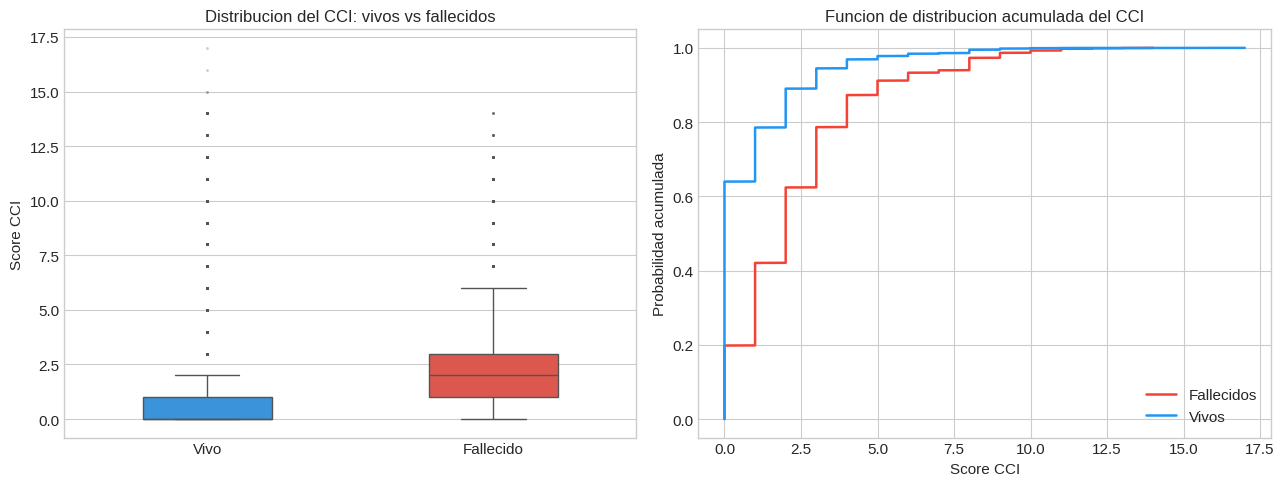

Resultado: U = 3265932302.00, p = 0.0000e+00, r = 0.1445


In [37]:
# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot CCI por grupo
df_plot = df[['CCI', 'FALLECIDO']].dropna().copy()
df_plot['Grupo'] = df_plot['FALLECIDO'].map({False: 'Vivo', True: 'Fallecido'})
sns.boxplot(data=df_plot, x='Grupo', y='CCI', palette={'Vivo': '#2196F3', 'Fallecido': '#F44336'},
            ax=axes[0], width=0.45, flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('Distribucion del CCI: vivos vs fallecidos', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score CCI')

# Distribucion acumulada (ECDF)
for grupo, color, label in [(True, '#F44336', 'Fallecidos'), (False, '#2196F3', 'Vivos')]:
    datos = df[df['FALLECIDO'] == grupo]['CCI'].dropna().sort_values()
    ecdf  = np.arange(1, len(datos) + 1) / len(datos)
    axes[1].plot(datos, ecdf, color=color, label=label, linewidth=1.8)
axes[1].set_title('Funcion de distribucion acumulada del CCI', fontsize=12)
axes[1].set_xlabel('Score CCI')
axes[1].set_ylabel('Probabilidad acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Resultado: U = {u_stat:.2f}, p = {p_valor_mw:.4e}, r = {r_effect:.4f}")


---
## 5.2: Verificacion de Normalidad — CCI y FALLECIDO

Antes de elegir Mann-Whitney U sobre una prueba t, debemos demostrar que
las distribuciones del CCI y de FALLECIDO no cumplen el supuesto de normalidad.
Usamos tres enfoques complementarios:

1. **Shapiro-Wilk** — prueba formal de normalidad (muestra <= 5000 por limitacion computacional).
2. **Kolmogorov-Smirnov** — alternativa para muestras grandes, compara contra una normal teorica.
3. **Visualizacion** — histograma + Q-Q plot, que son el estandar grafico para diagnosticar normalidad.

Verificacion de normalidad — CCI y FALLECIDO

Variable: CCI
  n                  = 394,638
  Media              = 0.8752
  Desv. estandar     = 1.5765
  Asimetria (skew)   = 2.7232
  Curtosis (excess)  = 9.4595
  Shapiro-Wilk       : W=0.612187, p=9.4378e-75  -> NO normal
  Kolmogorov-Smirnov : D=0.337603, p=0.0000e+00  -> NO normal

Variable: FALLECIDO
  n                  = 394,638
  Media              = 0.0288
  Desv. estandar     = 0.1673
  Asimetria (skew)   = 5.6331
  Curtosis (excess)  = 29.7323
  Shapiro-Wilk       : W=0.140887, p=2.7339e-92  -> NO normal
  Kolmogorov-Smirnov : D=0.539565, p=0.0000e+00  -> NO normal

Conclusion: ambas variables rechazan el supuesto de normalidad
(p << 0.05 en Shapiro-Wilk y Kolmogorov-Smirnov).
Esto justifica el uso de Mann-Whitney U en H2 y H3.


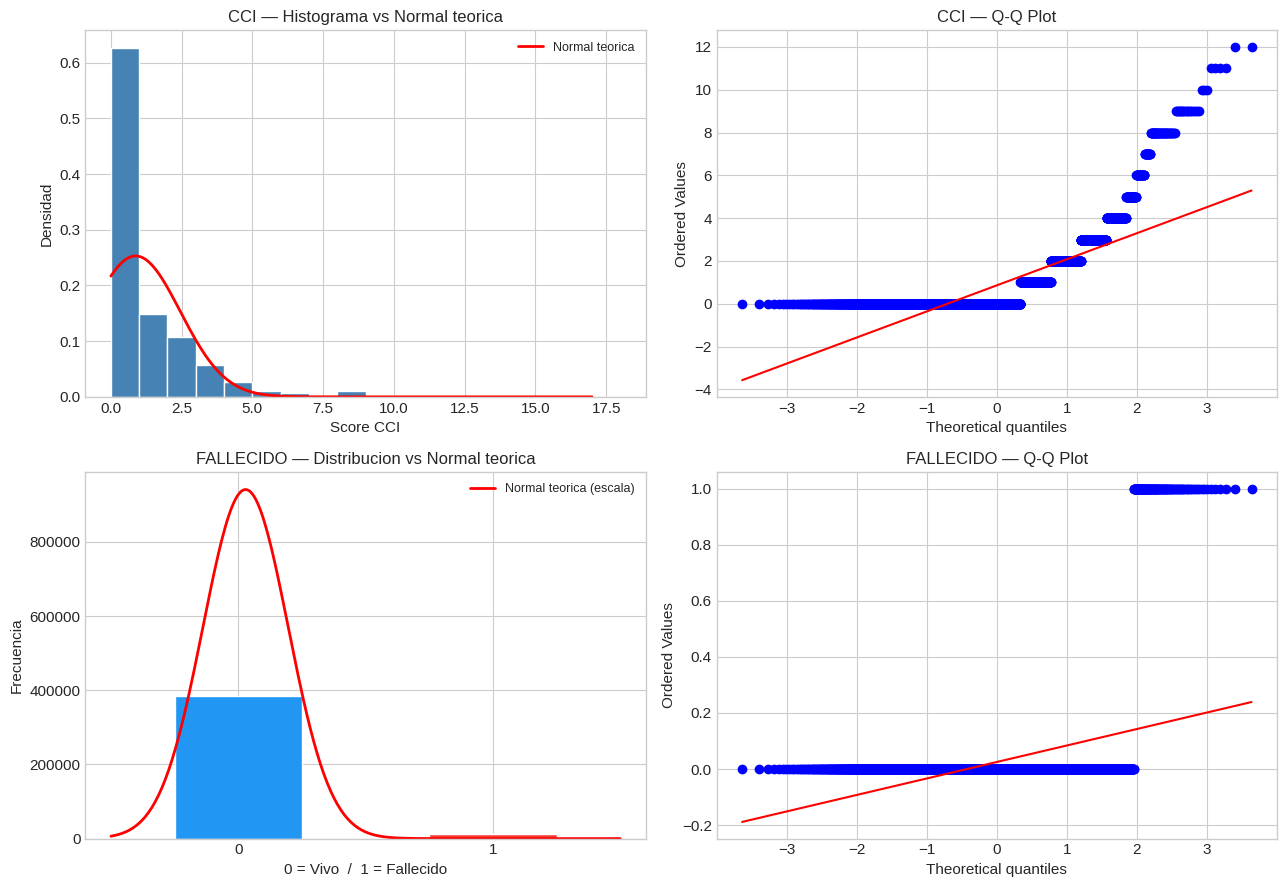

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')

# ── Datos ────────────────────────────────────────────────────────────────────
cci      = df['CCI'].dropna()
fallecido = df['FALLECIDO'].astype(int).dropna()

# ── Shapiro-Wilk (requiere muestra <= 5000) ──────────────────────────────────
muestra_cci = cci.sample(5000, random_state=42)
muestra_fal = fallecido.sample(5000, random_state=42)

sw_cci_stat, sw_cci_p = stats.shapiro(muestra_cci)
sw_fal_stat, sw_fal_p = stats.shapiro(muestra_fal)

# ── Kolmogorov-Smirnov vs normal teorica ─────────────────────────────────────
ks_cci_stat, ks_cci_p = stats.kstest(
    cci, 'norm', args=(cci.mean(), cci.std())
)
ks_fal_stat, ks_fal_p = stats.kstest(
    fallecido, 'norm', args=(fallecido.mean(), fallecido.std())
)

# ── Asimetria y curtosis ─────────────────────────────────────────────────────
print('Verificacion de normalidad — CCI y FALLECIDO')
print('=' * 58)
for nombre, serie, sw_s, sw_p, ks_s, ks_p in [
    ('CCI',       cci,      sw_cci_stat, sw_cci_p, ks_cci_stat, ks_cci_p),
    ('FALLECIDO', fallecido, sw_fal_stat, sw_fal_p, ks_fal_stat, ks_fal_p),
]:
    print(f'\nVariable: {nombre}')
    print(f'  n                  = {len(serie):,}')
    print(f'  Media              = {serie.mean():.4f}')
    print(f'  Desv. estandar     = {serie.std():.4f}')
    print(f'  Asimetria (skew)   = {stats.skew(serie):.4f}')
    print(f'  Curtosis (excess)  = {stats.kurtosis(serie):.4f}')
    print(f'  Shapiro-Wilk       : W={sw_s:.6f}, p={sw_p:.4e}  -> {"NO normal" if sw_p < 0.05 else "No se rechaza normalidad"}')
    print(f'  Kolmogorov-Smirnov : D={ks_s:.6f}, p={ks_p:.4e}  -> {"NO normal" if ks_p < 0.05 else "No se rechaza normalidad"}')

print()
print('Conclusion: ambas variables rechazan el supuesto de normalidad')
print('(p << 0.05 en Shapiro-Wilk y Kolmogorov-Smirnov).')
print('Esto justifica el uso de Mann-Whitney U en H2 y H3.')

# ── Visualizacion ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# CCI — histograma
axes[0, 0].hist(cci, bins=range(0, int(cci.max()) + 2), color='steelblue',
                edgecolor='white', density=True)
x_norm = np.linspace(cci.min(), cci.max(), 300)
axes[0, 0].plot(x_norm, stats.norm.pdf(x_norm, cci.mean(), cci.std()),
                color='red', linewidth=2, label='Normal teorica')
axes[0, 0].set_title('CCI — Histograma vs Normal teorica', fontsize=12)
axes[0, 0].set_xlabel('Score CCI')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend(fontsize=9)

# CCI — Q-Q plot
stats.probplot(muestra_cci, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('CCI — Q-Q Plot', fontsize=12)
axes[0, 1].get_lines()[1].set_color('red')

axes[1, 0].bar([0, 1], fallecido.value_counts().sort_index(),
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[1, 0].plot(x_norm := np.linspace(-0.5, 1.5, 300),
                stats.norm.pdf(x_norm, fallecido.mean(), fallecido.std()) * len(fallecido),
                color='red', linewidth=2, label='Normal teorica (escala)')
axes[1, 0].set_title('FALLECIDO — Distribucion vs Normal teorica', fontsize=12)
axes[1, 0].set_xlabel('0 = Vivo  /  1 = Fallecido')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].legend(fontsize=9)

stats.probplot(muestra_fal, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('FALLECIDO — Q-Q Plot', fontsize=12)
axes[1, 1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()